In [4]:
# Import library pandas untuk membaca dan mengolah data tabular (DataFrame)
import pandas as pd

# Membaca dataset gaji berdasarkan lama pengalaman kerja (Years of Experience)
df = pd.read_csv('Salary_Data.csv')

# Menampilkan 5 baris pertama untuk memastikan data terbaca dengan benar
print(df.head())

   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0


In [5]:
# X = semua kolom kecuali kolom terakhir -> di sini artinya kolom YearsExperience
# .values mengubah DataFrame/Series menjadi array numpy agar bisa diproses sklearn
X = df.iloc[:, :-1].values

# y = kolom kedua (index 1) -> kolom Salary, sebagai variabel target
y = df.iloc[:, 1].values

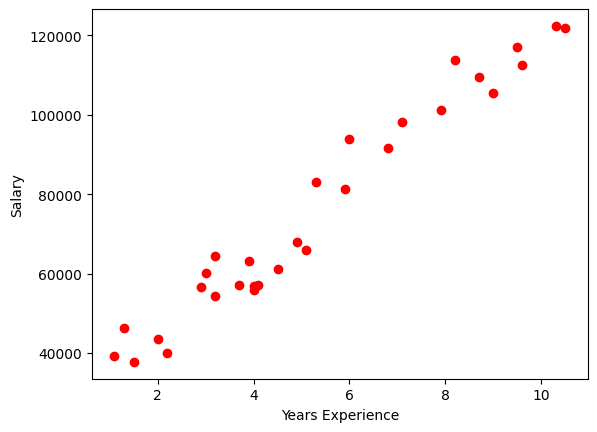

In [6]:
# Import matplotlib untuk membuat visualisasi (grafik)
import matplotlib.pyplot as plt

# Membuat scatter plot untuk melihat sebaran & pola hubungan
# antara Years Experience (X) dan Salary (y)
plt.scatter(X, y, color = "red")
plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.show()

In [7]:
# bagi dataset jadi train dan test 80:20
# train_test_split membagi data secara acak menjadi data latih (80%) dan data uji (20%)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [8]:
# Fitting Simple Linear Regression to the Training set
# LinearRegression() membuat objek model regresi linear kosong
# .fit() melatih model tersebut agar menemukan garis lurus terbaik
#   yang meminimalkan selisih (error) antara nilai aktual dan prediksi pada data training
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9312.58]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.678e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[12.65]


In [9]:
# intercept_ -> nilai konstanta a (titik potong garis dengan sumbu y)
a = regressor.intercept_

# coef_[0] -> nilai koefisien/slope b untuk variabel X pertama
b = regressor.coef_[0]

print("Estimated model intercept, a:", a)
print("Estimated model slope, b:", b)
# Menampilkan persamaan garis regresi dalam bentuk yang mudah dibaca
print(f"ŷ = {a:.2f} + {b:.2f}x")

Estimated model intercept, a: 26780.09915062818
Estimated model slope, b: 9312.575126729189
ŷ = 26780.10 + 9312.58x


In [10]:
# memprediksi hasil pada data uji (Test set) menggunakan model regresi yang telah dilatih
# .predict() memasukkan X_test ke dalam persamaan garis regresi untuk menghasilkan y prediksi
y_pred = regressor.predict(X_test)
y_pred

array([ 40748.96184072, 122699.62295594,  64961.65717022,  63099.14214487,
       115249.56285456, 107799.50275317])

In [12]:
# Menghitung nilai R-Square, yang mengukur seberapa baik model regresi linear
# menjelaskan variasi data. Semakin mendekati 1, semakin baik model

from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
score

0.988169515729126

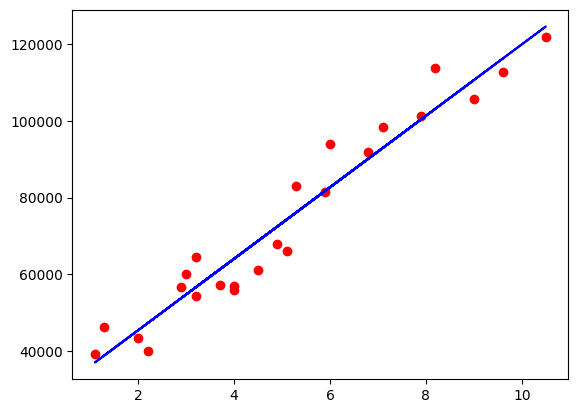

In [13]:
# Visualizing the Training set results
# Titik merah = data asli (aktual) pada data training
# Garis biru  = hasil prediksi model pada data training (garis regresi)
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.show()

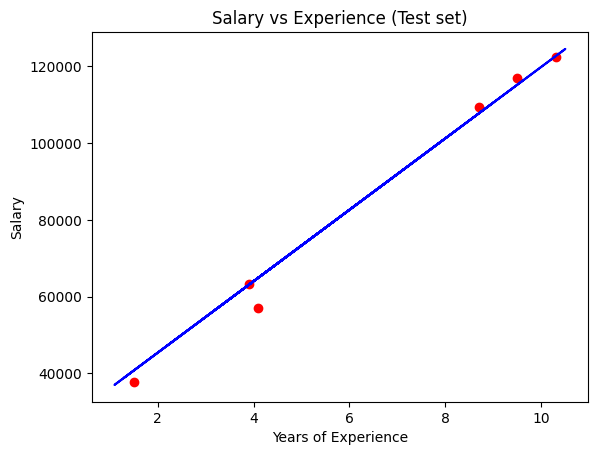

In [14]:
# Visualizing the Test set results
# Titik merah = data aktual pada data test (data yang belum pernah dilihat model)
# Garis biru  = garis regresi yang sama (dihasilkan dari data training),
#   dipakai untuk melihat seberapa cocok garis tersebut terhadap data baru
plt.scatter(X_test, y_test, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Salary vs Experience (Test set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

In [15]:
# Membaca dataset kedua: hubungan usia (age) dan pengalaman kerja (experience)
# terhadap pendapatan (income) -> di sini ada 2 variabel predictor sekaligus
df2 = pd.read_csv('multiple_linear_regression_dataset.csv')
print(df2.head())

   age  experience  income
0   25           1   30450
1   30           3   35670
2   47           2   31580
3   32           5   40130
4   43          10   47830


In [16]:
# X2 = semua kolom kecuali kolom terakhir -> age dan experience
X2 = df2.iloc[:, :-1]

# y2 = kolom ke-3 (index 2) -> income, sebagai target
y2 = df2.iloc[:, 2]

In [17]:
# Bagi dataset menjadi train dan test 80:20
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size = 0.2, random_state = 0)

In [18]:
# Sama seperti sebelumnya, tapi sekarang model belajar dari 2 variabel predictor sekaligus
# (age dan experience) untuk memprediksi income
regressor = LinearRegression()
regressor.fit(X_train2, y_train2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ -97.99,2205.91]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['age','experience']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.095e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [19]:
# Predicting the Test set results
y_pred2 = regressor.predict(X_test2)
print(y_pred2)

[46487.25542968 34623.71312375 49379.11875301 38349.57565764]


In [20]:
# a_ = intercept model (nilai y saat semua x = 0)
a_ = regressor.intercept_
# b1 = koefisien untuk predictor pertama (age)
b1 = regressor.coef_[0]
# b2 = koefisien untuk predictor kedua (experience)
b2 = regressor.coef_[1]

print("Estimated model intercept, a:", a_)
print("Estimated model slope, b1:", b1)
print("Estimated model slope, b2:", b2)
print(f"ŷ = {a_:.2f} + {b1:.2f}x1 + {b2:.2f}x2")

Estimated model intercept, a: 30945.793141906892
Estimated model slope, b1: -97.99352917934205
Estimated model slope, b2: 2205.9086190738694
ŷ = 30945.79 + -97.99x1 + 2205.91x2


In [21]:
# Menghitung nilai R-Square, yang mengukur seberapa baik model regresi linear
# Semakin mendekati 1, semakin baik model

score2 = r2_score(y_test2, y_pred2)
score2

0.8872690560355565

## Tugas 1

In [23]:
# ---------------------------------------------------------
# 1. Load dataset
# Ganti 'student_scores.csv' dengan file asli hasil download dari Kaggle
# Pastikan nama kolomnya sesuai (di sini: 'Hours' dan 'Scores')
# ---------------------------------------------------------
df_t1 = pd.read_csv('student_scores.csv')
print(df_t1.head())

   Hours  Scores
0    4.0    49.9
1    8.6    99.7
2    6.9    93.3
3    5.8    72.1
4    2.2    36.5


In [24]:
# ---------------------------------------------------------
# 2. Menentukan predictor (X) dan target (y)
# X = Hours (waktu belajar) -> variabel independen
# y = Scores (nilai ujian)  -> variabel dependen / target
# ---------------------------------------------------------
X_t1 = df_t1[['Hours']].values   # dibuat 2D karena sklearn butuh bentuk (n_samples, n_features)
y_t1 = df_t1['Scores'].values

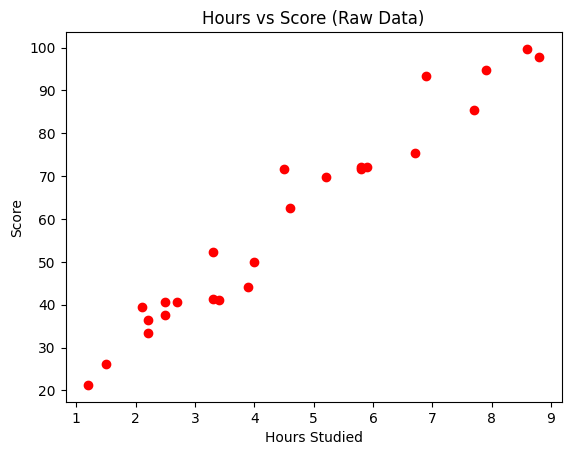

In [25]:
# ---------------------------------------------------------
# 3. Visualisasi awal data (scatter plot)
# Tujuannya melihat pola hubungan antara Hours dan Scores sebelum melatih model
# ---------------------------------------------------------
plt.scatter(X_t1, y_t1, color="red")
plt.xlabel('Hours Studied')
plt.ylabel('Score')
plt.title('Hours vs Score (Raw Data)')
plt.show()

In [26]:
# ---------------------------------------------------------
# 4. Split dataset menjadi data training dan testing (80:20)
# ---------------------------------------------------------
X_train_t1, X_test_t1, y_train_t1, y_test_t1 = train_test_split(
    X_t1, y_t1, test_size=0.2, random_state=0
)

In [27]:
# ---------------------------------------------------------
# 5. Melatih model Simple Linear Regression
# Model mencari garis lurus terbaik: y_hat = a + b*x
# yang paling mendekati data pada X_train dan y_train
# ---------------------------------------------------------
regressor_t1 = LinearRegression()
regressor_t1.fit(X_train_t1, y_train_t1)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[10.02]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,13.25
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[9.67]


In [28]:
# ---------------------------------------------------------
# 6. Menampilkan persamaan garis regresi
# a = intercept -> nilai y saat x = 0
# b = slope/koefisien -> seberapa besar kenaikan y saat x naik 1 satuan
# ---------------------------------------------------------
a_t1 = regressor_t1.intercept_
b_t1 = regressor_t1.coef_[0]

print("Estimated model intercept, a:", a_t1)
print("Estimated model slope, b:", b_t1)
print(f"Persamaan regresi: ŷ = {a_t1:.2f} + {b_t1:.2f}x")

Estimated model intercept, a: 13.247100254757974
Estimated model slope, b: 10.023227933463211
Persamaan regresi: ŷ = 13.25 + 10.02x


In [29]:
# ---------------------------------------------------------
# 7. Memprediksi nilai Score pada data uji (X_test)
# ---------------------------------------------------------
y_pred_t1 = regressor_t1.predict(X_test_t1)
print("Prediksi:", y_pred_t1)
print("Aktual  :", y_test_t1)

Prediksi: [ 35.29820171  82.407373    46.32375244  47.32607523 101.45150607]
Aktual  : [33.3 93.3 52.3 41.  97.8]


In [30]:
# ---------------------------------------------------------
# 8. Evaluasi performa model dengan R-Square (R²)
# R² mengukur seberapa besar variasi y yang bisa dijelaskan oleh model.
# Semakin mendekati 1, semakin baik modelnya.
# ---------------------------------------------------------
score_t1 = r2_score(y_test_t1, y_pred_t1)
print("R-Square:", score_t1)

R-Square: 0.9413260513817172


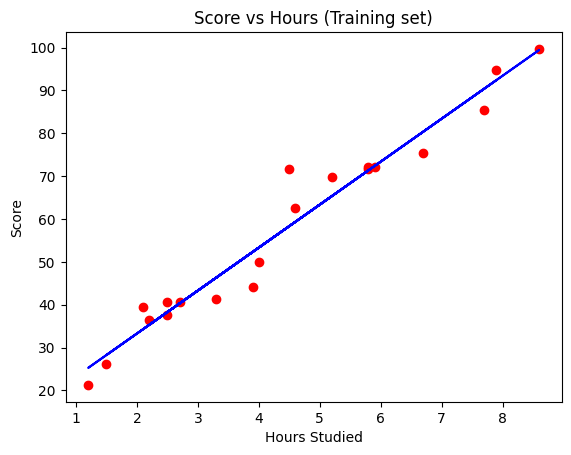

In [31]:
# ---------------------------------------------------------
# 9. Visualisasi hasil pada data Training
# Titik merah = data asli, garis biru = hasil prediksi model (garis regresi)
# ---------------------------------------------------------
plt.scatter(X_train_t1, y_train_t1, color='red')
plt.plot(X_train_t1, regressor_t1.predict(X_train_t1), color='blue')
plt.title('Score vs Hours (Training set)')
plt.xlabel('Hours Studied')
plt.ylabel('Score')
plt.show()

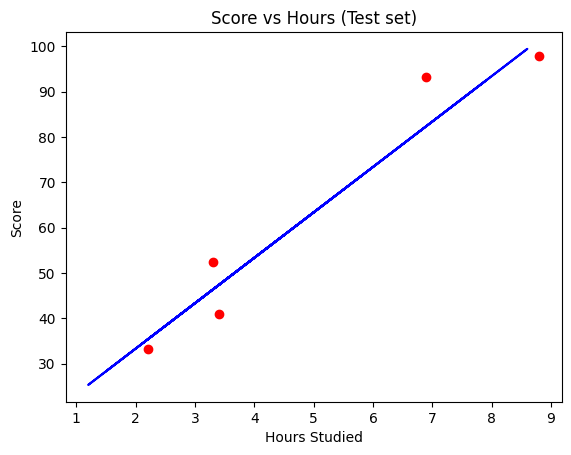

In [32]:
# ---------------------------------------------------------
# 10. Visualisasi hasil pada data Testing
# Untuk melihat seberapa dekat garis regresi (dari data training)
# terhadap data yang belum pernah dilihat model (data test)
# ---------------------------------------------------------
plt.scatter(X_test_t1, y_test_t1, color='red')
plt.plot(X_train_t1, regressor_t1.predict(X_train_t1), color='blue')
plt.title('Score vs Hours (Test set)')
plt.xlabel('Hours Studied')
plt.ylabel('Score')
plt.show()

## Tugas 2

In [33]:
# ---------------------------------------------------------
# 1. Load dataset
# Ganti 'marketing.csv' dengan file asli hasil download dari Kaggle
# Pastikan nama kolomnya sesuai: youtube, facebook, newspaper, sales
# ---------------------------------------------------------
df_t2 = pd.read_csv('marketing.csv')
print(df_t2.head())

   youtube  facebook  newspaper  sales
0     26.7       4.2       75.2   5.65
1    273.0      21.4        6.2  20.06
2    153.4      48.8       74.5  19.28
3    253.2      25.7       94.6  19.34
4    342.3      36.0       60.4  26.66


In [34]:
# ---------------------------------------------------------
# 2. Menentukan predictor (X) dan target (y)
# X2 = biaya iklan youtube, facebook, newspaper -> 3 variabel independen
# y2 = sales -> target/variabel dependen
# ---------------------------------------------------------
X_t2 = df_t2[['youtube', 'facebook', 'newspaper']]
y_t2 = df_t2['sales']

In [35]:
# ---------------------------------------------------------
# 3. Split dataset menjadi data training dan testing (80:20)
# ---------------------------------------------------------
X_train_t2, X_test_t2, y_train_t2, y_test_t2 = train_test_split(
    X_t2, y_t2, test_size=0.2, random_state=0
)

In [36]:
# ---------------------------------------------------------
# 4. Melatih model Multiple Linear Regression
# Sama seperti Simple Linear Regression, tapi sekarang modelnya:
# y_hat = a + b1*x1 + b2*x2 + b3*x3
# karena ada 3 variabel predictor sekaligus
# ---------------------------------------------------------
regressor_t2 = LinearRegression()
regressor_t2.fit(X_train_t2, y_train_t2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.05,0.19,0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['youtube','facebook','newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.433
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [37]:
# ---------------------------------------------------------
# 5. Memprediksi hasil pada data uji (Test set)
# ---------------------------------------------------------
y_pred_t2 = regressor_t2.predict(X_test_t2)
print("Prediksi:", y_pred_t2)
print("Aktual  :", y_test_t2.values)

Prediksi: [17.54408247 14.87717157 19.5981388   6.79465205 11.35750755 22.13904437
  7.94769406 10.99417192 10.8543078  16.17090094 16.21702059  5.85736536
  9.98977104 10.98811491 12.93048255  8.15699214  8.57369268 27.94189173
 12.69148301  7.33345958]
Aktual  : [17.52 14.03 19.28  7.09 11.89 21.98  9.45 11.37  8.9  14.61 13.62  6.98
 10.15  8.92 14.46  8.65  8.86 27.24 13.78  9.33]


In [38]:
# ---------------------------------------------------------
# 6. Menampilkan intercept dan koefisien tiap variabel
# a  = intercept -> nilai y saat semua x = 0
# b1 = koefisien youtube -> pengaruh iklan youtube terhadap sales
# b2 = koefisien facebook -> pengaruh iklan facebook terhadap sales
# b3 = koefisien newspaper -> pengaruh iklan newspaper terhadap sales
# ---------------------------------------------------------
a_t2 = regressor_t2.intercept_
b1_t2 = regressor_t2.coef_[0]
b2_t2 = regressor_t2.coef_[1]
b3_t2 = regressor_t2.coef_[2]

print("Estimated model intercept, a:", a_t2)
print("Estimated model slope, b1 (youtube):", b1_t2)
print("Estimated model slope, b2 (facebook):", b2_t2)
print("Estimated model slope, b3 (newspaper):", b3_t2)
print(f"Persamaan regresi: ŷ = {a_t2:.2f} + {b1_t2:.4f}x1 + {b2_t2:.4f}x2 + {b3_t2:.4f}x3")

Estimated model intercept, a: 2.4330212371456614
Estimated model slope, b1 (youtube): 0.046993571048621056
Estimated model slope, b2 (facebook): 0.1945926975867205
Estimated model slope, b3 (newspaper): 0.006176914443356024
Persamaan regresi: ŷ = 2.43 + 0.0470x1 + 0.1946x2 + 0.0062x3


In [39]:
# ---------------------------------------------------------
# 7. Evaluasi performa model dengan R-Square (R²)
# Semakin mendekati 1, semakin baik model menjelaskan variasi sales
# ---------------------------------------------------------
score_t2 = r2_score(y_test_t2, y_pred_t2)
print("R-Square:", score_t2)

R-Square: 0.9422966169720187


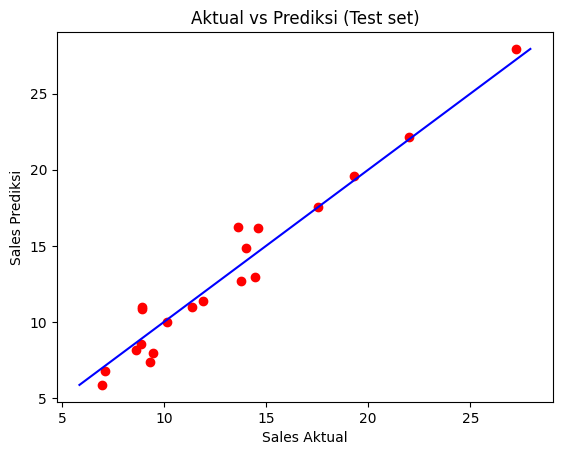

In [40]:
# ---------------------------------------------------------
# 8. Visualisasi tambahan: Aktual vs Prediksi
# Karena Multiple Linear Regression punya 3 variabel input,
# tidak bisa divisualisasikan dalam 1 garis 2D seperti Simple Linear Regression.
# Sebagai gantinya, kita bandingkan nilai aktual vs prediksi.
# Semakin titik-titik mendekati garis diagonal, semakin akurat model.
# ---------------------------------------------------------
plt.scatter(y_test_t2, y_pred_t2, color='red')
min_val = min(y_test_t2.min(), y_pred_t2.min())
max_val = max(y_test_t2.max(), y_pred_t2.max())
plt.plot([min_val, max_val], [min_val, max_val], color='blue')  # garis referensi ideal
plt.xlabel('Sales Aktual')
plt.ylabel('Sales Prediksi')
plt.title('Aktual vs Prediksi (Test set)')
plt.show()